In [ ]:
import os
#KAGGLE GATZAN DATASET IMPORT
# Insert your own Kaggle credentials before running
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KAGGLE_API_KEY"

# Kaggle kütüphanesini kur
!pip install -q kaggle

# GTZAN veri setini indir
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification

# Zip dosyasını gtzan_data klasörüne çıkar
!unzip -q gtzan-dataset-music-genre-classification.zip -d gtzan_data

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:14<00:00, 92.7MB/s]



In [ ]:
import os

# Sadece GTZAN türlerini alalım (Klasör isimlerinden)
gtzan_dir = '/content/gtzan_data/Data/genres_original'
# Eğer yol Data altında değilse alternatif yolu kontrol et
if not os.path.exists(gtzan_dir):
    gtzan_dir = '/content/gtzan_data/genres_original'

if os.path.exists(gtzan_dir):
    gtzan_genres = sorted([d for d in os.listdir(gtzan_dir) if os.path.isdir(os.path.join(gtzan_dir, d))])
    print(f"GTZAN Türleri: {gtzan_genres}")
    print(f"Toplam Tür Sayısı: {len(gtzan_genres)}")
else:
    print("Hata: GTZAN veri seti klasörü bulunamadı. Lütfen datasetin doğru çıkarıldığından emin olun.")

GTZAN Türleri: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Toplam Tür Sayısı: 10


In [ ]:
!git clone https://github.com/anjul1008/AudioSignalProcessingForMachineLearning.git

Cloning into 'AudioSignalProcessingForMachineLearning'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 108 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 59.04 MiB | 12.21 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (59/59), done.


In [ ]:
import os
import glob
from sklearn.model_selection import train_test_split

# GTZAN veri yolu kontrol
gtzan_dir = '/content/gtzan_data/Data/genres_original'
if not os.path.exists(gtzan_dir):
    gtzan_dir = '/content/gtzan_data/genres_original'

# Tüm dosya yollarını ve etiketleri topla
all_files = []
all_labels = []

genres = [d for d in os.listdir(gtzan_dir) if os.path.isdir(os.path.join(gtzan_dir, d))]

for genre in genres:
    genre_path = os.path.join(gtzan_dir, genre)
    file_pattern = os.path.join(genre_path, '*.wav')
    files = glob.glob(file_pattern)
    all_files.extend(files)
    all_labels.extend([genre] * len(files))

# Veri bölme
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_files, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"Toplam Dosya: {len(all_files)}")
print(f"Eğitim seti: {len(train_paths)}, Doğrulama: {len(val_paths)}, Test: {len(test_paths)}")

Toplam Dosya: 1000
Eğitim seti: 700, Doğrulama: 150, Test: 150


In [ ]:
import librosa
import numpy as np
from sklearn.preprocessing import LabelEncoder

def extract_mfcc_features(file_paths, labels, sr=22050, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10):
    X = []
    y = []

    # Sabit segment uzunluğu hesapla (30 saniyelik GTZAN dosyaları için)
    samples_per_track = sr * 30
    samples_per_segment = int(samples_per_track / num_segments)
    # Her segment için beklenen MFCC vektör sayısı
    expected_mfcc_vectors_per_segment = int(np.ceil(samples_per_segment / hop_length))

    for i, (file_path, label) in enumerate(zip(file_paths, labels)):
        try:
            # Sesi yükle
            signal, _ = librosa.load(file_path, sr=sr)

            # Dosyayı parçalara böl
            for s in range(num_segments):
                start_sample = samples_per_segment * s
                finish_sample = start_sample + samples_per_segment

                segment = signal[start_sample:finish_sample]

                # MFCC çıkarımı
                mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
                mfcc = mfcc.T

                # Boyut kontrolü (Segmentin tam olduğundan emin ol)
                if len(mfcc) == expected_mfcc_vectors_per_segment:
                    X.append(mfcc.tolist())
                    y.append(label)
        except Exception as e:
            print(f"Hata ({file_path}): {e}")

    return np.array(X), np.array(y)

# Etiketleri encode etmek için LabelEncoder nesnesini hazırla
le = LabelEncoder()
le.fit(all_labels)

# Setleri işle (Augmentation yok)
print("Eğitim seti işleniyor...")
X_train, y_train_raw = extract_mfcc_features(train_paths, train_labels)

print("Doğrulama seti işleniyor...")
X_val, y_val_raw = extract_mfcc_features(val_paths, val_labels)

print("Test seti işleniyor...")
X_test, y_test_raw = extract_mfcc_features(test_paths, test_labels)

# Ham etiketleri sayısal değerlere dönüştür
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
y_test = le.transform(y_test_raw)

print("\nİşlem Tamamlandı!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Eğitim seti işleniyor...


/tmp/ipykernel_4443/3101994730.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Hata (/content/gtzan_data/Data/genres_original/jazz/jazz.00054.wav): 
Doğrulama seti işleniyor...
Test seti işleniyor...

İşlem Tamamlandı!
X_train shape: (6987, 130, 13), y_train shape: (6987,)
X_val shape: (1499, 130, 13), y_val shape: (1499,)
X_test shape: (1500, 130, 13), y_test shape: (1500,)


In [ ]:
import tensorflow.keras as keras
from tensorflow.keras import layers

# Keras hafızasını temizle
keras.backend.clear_session()

# Giriş boyutlarını belirle (Flatten işlemi gerekecek)
input_shape = (X_train.shape[1], X_train.shape[2])

# Basit MLP modeli oluştur
model = keras.Sequential([
    layers.Flatten(input_shape=input_shape),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])

# Modeli derle
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# EarlyStopping tanımla
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Modeli eğit
history_mlp_no_aug = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Test seti ile nihai başarıyı yazdır
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Doğruluğu: {test_acc:.4f}")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1391 - loss: 8.3173 - val_accuracy: 0.1167 - val_loss: 2.6777
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1456 - loss: 2.3176 - val_accuracy: 0.1608 - val_loss: 2.6826
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.1948 - loss: 2.1584 - val_accuracy: 0.2402 - val_loss: 2.4837
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.2038 - loss: 2.1419 - val_accuracy: 0.1648 - val_loss: 2.5841
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.2070 - loss: 2.0991 - val_accuracy: 0.2462 - val_loss: 2.4189
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.2386 - loss: 2.0468 - val_accuracy: 0.2742 - val_loss: 2.4834
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.2612 - loss: 1.9895 - val_accuracy: 0.2615 - val_loss: 2.4856
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.2641 - loss: 1.9562 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       865,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,042,656 (11.61 MB)

 Trainable params: 1,014,218 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,028,438 (7.74 MB)

In [ ]:
import numpy as np

# Mevcut history nesnesinden metrikleri sözlük olarak al
mlp_metrics = {
    'accuracy': history_mlp_no_aug.history['accuracy'],
    'loss': history_mlp_no_aug.history['loss'],
    'val_accuracy': history_mlp_no_aug.history['val_accuracy'],
    'val_loss': history_mlp_no_aug.history['val_loss']
}

# val_loss'un en düşük olduğu (en iyi) epoch indexini bul (1 tabanlı)
best_epoch = np.argmin(mlp_metrics['val_loss']) + 1

# Bilgileri ekrana yazdır
print(f"Eğitim {len(mlp_metrics['loss'])} epoch sürdü.")
print(f"En iyi sonuca ulaşılan epoch (Validation Loss bazlı): {best_epoch}")
print("Metrikler 'mlp_metrics' değişkenine başarıyla kaydedildi.")

Eğitim 53 epoch sürdü.
En iyi sonuca ulaşılan epoch (Validation Loss bazlı): 43
Metrikler 'mlp_metrics' değişkenine başarıyla kaydedildi.


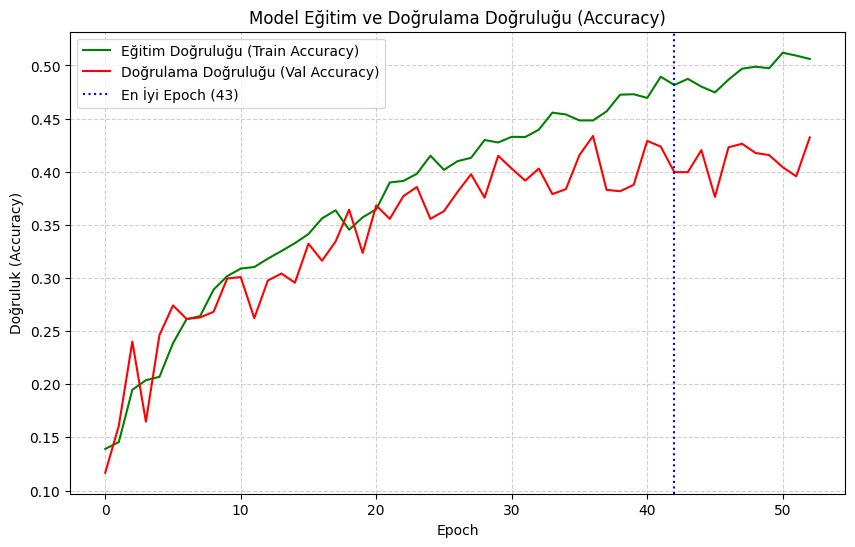

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grafik boyutunu ayarla
plt.figure(figsize=(10, 6))

# Eğitim ve doğrulama doğruluğunu çiz
plt.plot(mlp_metrics['accuracy'], label='Eğitim Doğruluğu (Train Accuracy)', color='green')
plt.plot(mlp_metrics['val_accuracy'], label='Doğrulama Doğruluğu (Val Accuracy)', color='red')

# Grafik başlığı ve etiketler
plt.title('Model Eğitim ve Doğrulama Doğruluğu (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Kayıp grafiğindeki en iyi epoch'u burada da işaretleyelim
best_epoch_idx = np.argmin(mlp_metrics['val_loss'])
plt.axvline(x=best_epoch_idx, color='blue', linestyle=':', label=f'En İyi Epoch ({best_epoch_idx+1})')
plt.legend()

plt.show()

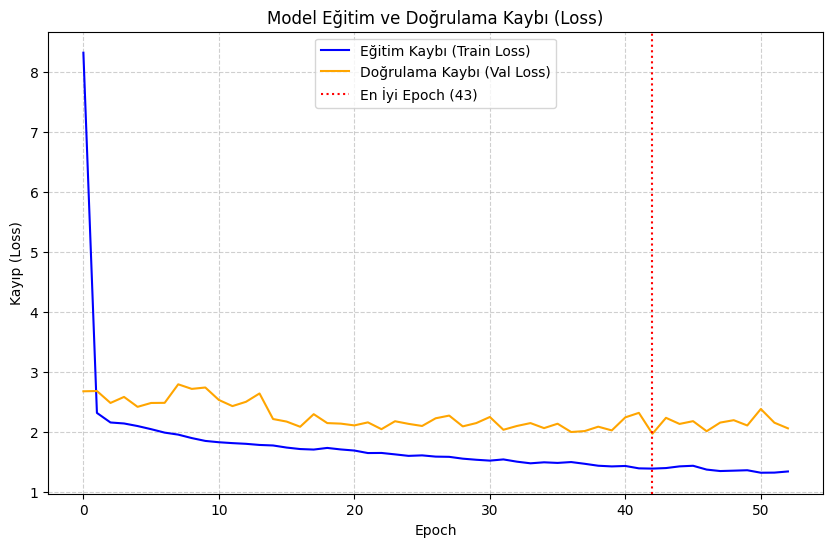

In [ ]:
import matplotlib.pyplot as plt

# Grafik boyutunu ayarla
plt.figure(figsize=(10, 6))

# Eğitim ve doğrulama kaybını çiz
plt.plot(mlp_metrics['loss'], label='Eğitim Kaybı (Train Loss)', color='blue')
plt.plot(mlp_metrics['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='orange')

# Grafik başlığı ve etiketler
plt.title('Model Eğitim ve Doğrulama Kaybı (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# En iyi epoch'u işaretle (isteğe bağlı)
best_epoch_idx = np.argmin(mlp_metrics['val_loss'])
plt.axvline(x=best_epoch_idx, color='red', linestyle=':', label=f'En İyi Epoch ({best_epoch_idx+1})')
plt.legend()

plt.show()

In [ ]:
import os

# Insert your own Kaggle credentials before running
os.environ['KAGGLE_USERNAME'] = "YOUR_KAGGLE_USERNAME"
os.environ['KAGGLE_KEY'] = "YOUR_KAGGLE_API_KEY"

# Belirttiğiniz FMA veri setini indir
print("FMA veri seti (small-medium) indiriliyor...")
!kaggle datasets download -d imsparsh/fma-free-music-archive-small-medium

# Klasör oluştur ve çıkar
!mkdir -p fma_data
!unzip -q fma-free-music-archive-small-medium.zip -d fma_data

print("İşlem tamamlandı.")

FMA veri seti (small-medium) indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium
License(s): CC0-1.0
100% 29.8G/29.8G [05:58<00:00, 89.2MB/s]

İşlem tamamlandı.


In [ ]:
import librosa
import numpy as np

def extract_features_with_augmentation(file_paths, labels, augment=False, sr=22050, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10):
    X = []
    y = []
    samples_per_track = sr * 30
    samples_per_segment = int(samples_per_track / num_segments)
    expected_vectors = int(np.ceil(samples_per_segment / hop_length))

    for file_path, label in zip(file_paths, labels):
        try:
            signal, _ = librosa.load(file_path, sr=sr)

            # Fonksiyon: Özellik çıkarımı ve listeye ekleme
            def process_signal(sig, lbl):
                for s in range(num_segments):
                    start = samples_per_segment * s
                    finish = start + samples_per_segment
                    segment = sig[start:finish]
                    if len(segment) < samples_per_segment: continue
                    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length).T
                    if len(mfcc) == expected_vectors:
                        X.append(mfcc.tolist())
                        y.append(lbl)

            # Orijinal sinyali işle
            process_signal(signal, label)

            # Eğer augment aktifse gürültü ekle (Sadece eğitim seti için)
            if augment:
                # 1. White Noise ekleme
                noise = np.random.randn(len(signal))
                noisy_signal = signal + 0.005 * noise
                process_signal(noisy_signal, label)

                # 2. Zaman kaydırma (Shift)
                shifted_signal = np.roll(signal, int(sr * 0.5))
                process_signal(shifted_signal, label)

        except Exception as e:
            print(f"Hata ({file_path}): {e}")

    return np.array(X), np.array(y)

print("Eğitim seti artırılarak (Augmented) işleniyor...")
X_train_aug, y_train_aug_raw = extract_features_with_augmentation(train_paths, train_labels, augment=True)

# Ham etiketleri sayısal değerlere dönüştür
y_train_aug = le.transform(y_train_aug_raw)

print(f"Yeni Eğitim Seti Boyutu: {X_train_aug.shape}")

Eğitim seti artırılarak (Augmented) işleniyor...


/tmp/ipykernel_4443/1683176518.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Hata (/content/gtzan_data/Data/genres_original/jazz/jazz.00054.wav): 
Yeni Eğitim Seti Boyutu: (20949, 130, 13)


In [ ]:
keras.backend.clear_session()

model_aug = keras.Sequential([
    layers.Flatten(input_shape=(X_train_aug.shape[1], X_train_aug.shape[2])),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(le.classes_), activation='softmax')
])

model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Modeli eğit
history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Test seti ile başarıyı ölç
aug_test_loss, aug_test_acc = model_aug.evaluate(X_test, y_test, verbose=0)
print(f"\nAugmentation Sonrası Test Doğruluğu: {aug_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.1501 - loss: 4.1504 - val_accuracy: 0.2048 - val_loss: 3.3974
Epoch 2/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.1887 - loss: 2.1512 - val_accuracy: 0.2282 - val_loss: 2.9610
Epoch 3/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.2208 - loss: 2.0685 - val_accuracy: 0.2642 - val_loss: 2.7595
Epoch 4/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.2744 - loss: 1.9271 - val_accuracy: 0.3029 - val_loss: 2.2534
Epoch 5/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3106 - loss: 1.8435 - val_accuracy: 0.2975 - val_loss: 2.2122
Epoch 6/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.3345 - loss: 1.7856 - val_accuracy: 0.3669 - val_loss: 2.0864
Epoch 7/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3471 - loss: 1.7593 - val_accuracy: 0.3242 - val_loss: 2.0967
Epoch 8/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.3668 - loss: 1

In [ ]:
import numpy as np

# Augmented modelin history nesnesinden metrikleri al
aug_metrics = {
    'accuracy': history_aug.history['accuracy'],
    'loss': history_aug.history['loss'],
    'val_accuracy': history_aug.history['val_accuracy'],
    'val_loss': history_aug.history['val_loss']
}

# val_loss'un en düşük olduğu en iyi epoch indexini bul (1 tabanlı)
best_epoch_aug = np.argmin(aug_metrics['val_loss']) + 1

# Bilgileri ekrana yazdır
print(f"Augmented Model Eđitimi {len(aug_metrics['loss'])} epoch s&uuml;rd&uuml;.")
print(f"En iyi Val Loss deđerine ulařılan epoch: {best_epoch_aug}")
print("Metrikler 'aug_metrics' deđiřkenine kaydedildi.")

Augmented Model Eđitimi 24 epoch s&uuml;rd&uuml;.
En iyi Val Loss deđerine ulařılan epoch: 14
Metrikler 'aug_metrics' deđiřkenine kaydedildi.


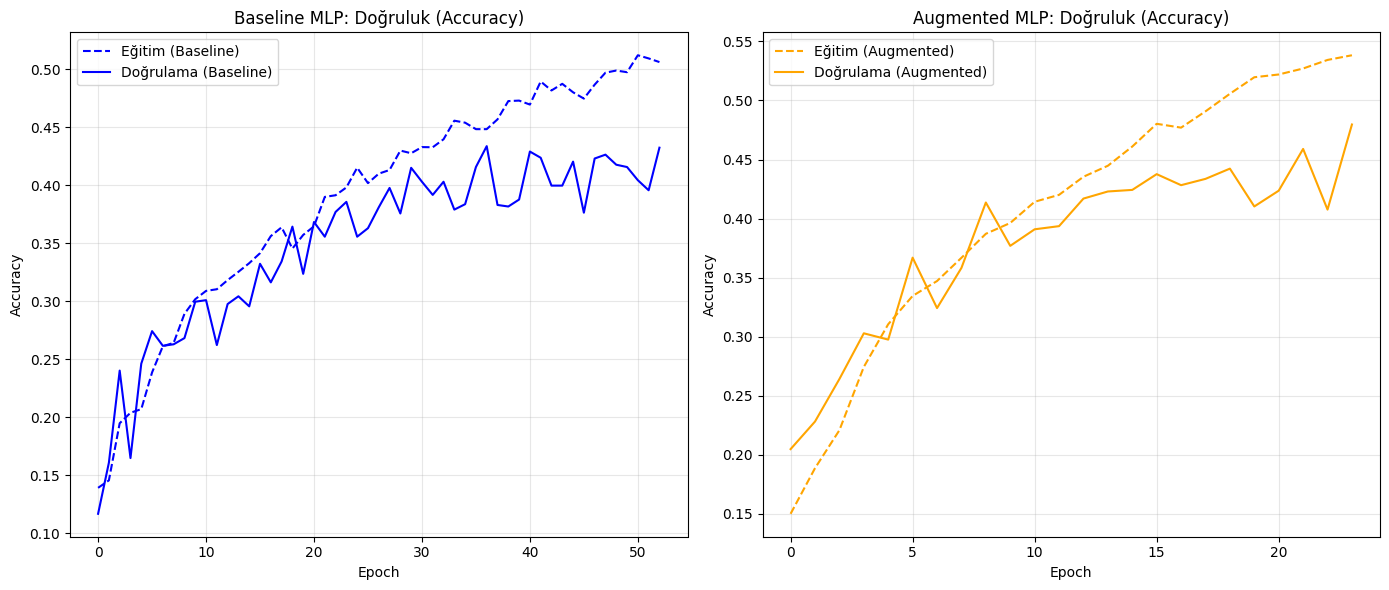

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Baseline Model Grafiği
plt.subplot(1, 2, 1)
plt.plot(mlp_metrics['accuracy'], label='Eğitim (Baseline)', color='blue', linestyle='--')
plt.plot(mlp_metrics['val_accuracy'], label='Doğrulama (Baseline)', color='blue')
plt.title('Baseline MLP: Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Augmented Model Grafiği
plt.subplot(1, 2, 2)
plt.plot(aug_metrics['accuracy'], label='Eğitim (Augmented)', color='orange', linestyle='--')
plt.plot(aug_metrics['val_accuracy'], label='Doğrulama (Augmented)', color='orange')
plt.title('Augmented MLP: Doğruluk (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras import layers
import numpy as np

# 1. Keras hafızasını temizle
keras.backend.clear_session()

# 2. Veriyi CNN için yeniden şekillendir (Samples, Time, MFCC, Channel)
X_train_cnn = X_train_aug[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

input_shape = (X_train_cnn.shape[1], X_train_cnn.shape[2], 1)

# 3. CNN Modeli İnşa Et
model_cnn = keras.Sequential([
    # 1. Conv Blok
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    # 2. Conv Blok
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    # 3. Conv Blok
    layers.Conv2D(128, (2, 2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'),

    # Sınıflandırma Katmanları
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(le.classes_), activation='softmax')
])

# 4. Derle
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. EarlyStopping Tanımla
early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 6. Eğit
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_aug,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)

# 7. Metrikleri Kaydet ve En İyi Epoch'u Bul
cnn_metrics = {
    'accuracy': history_cnn.history['accuracy'],
    'loss': history_cnn.history['loss'],
    'val_accuracy': history_cnn.history['val_accuracy'],
    'val_loss': history_cnn.history['val_loss']
}

best_epoch_cnn = np.argmin(cnn_metrics['val_loss']) + 1
print(f"\nCNN Eğitimi Tamamlandı!")
print(f"En iyi Val Loss değerine ulaşılan epoch: {best_epoch_cnn}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 73s 105ms/step - accuracy: 0.5323 - loss: 1.3672 - val_accuracy: 0.5997 - val_loss: 1.3807
Epoch 2/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 68s 103ms/step - accuracy: 0.6897 - loss: 0.8906 - val_accuracy: 0.6444 - val_loss: 1.2468
Epoch 3/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.7547 - loss: 0.6956 - val_accuracy: 0.6611 - val_loss: 1.3514
Epoch 4/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.8015 - loss: 0.5656 - val_accuracy: 0.6424 - val_loss: 1.5156
Epoch 5/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.8289 - loss: 0.4843 - val_accuracy: 0.6811 - val_loss: 1.4436
Epoch 6/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 102ms/step - accuracy: 0.8596 - loss: 0.4076 - val_accuracy: 0.6671 - val_loss: 1.5487
Epoch 7/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 86s 108ms/step - accuracy: 0.8759 - loss: 0.3551 - val_accuracy: 0.6771 - val_loss: 1.7851
Epoch 8/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 68s 104ms/step - accuracy: 0.8939 -

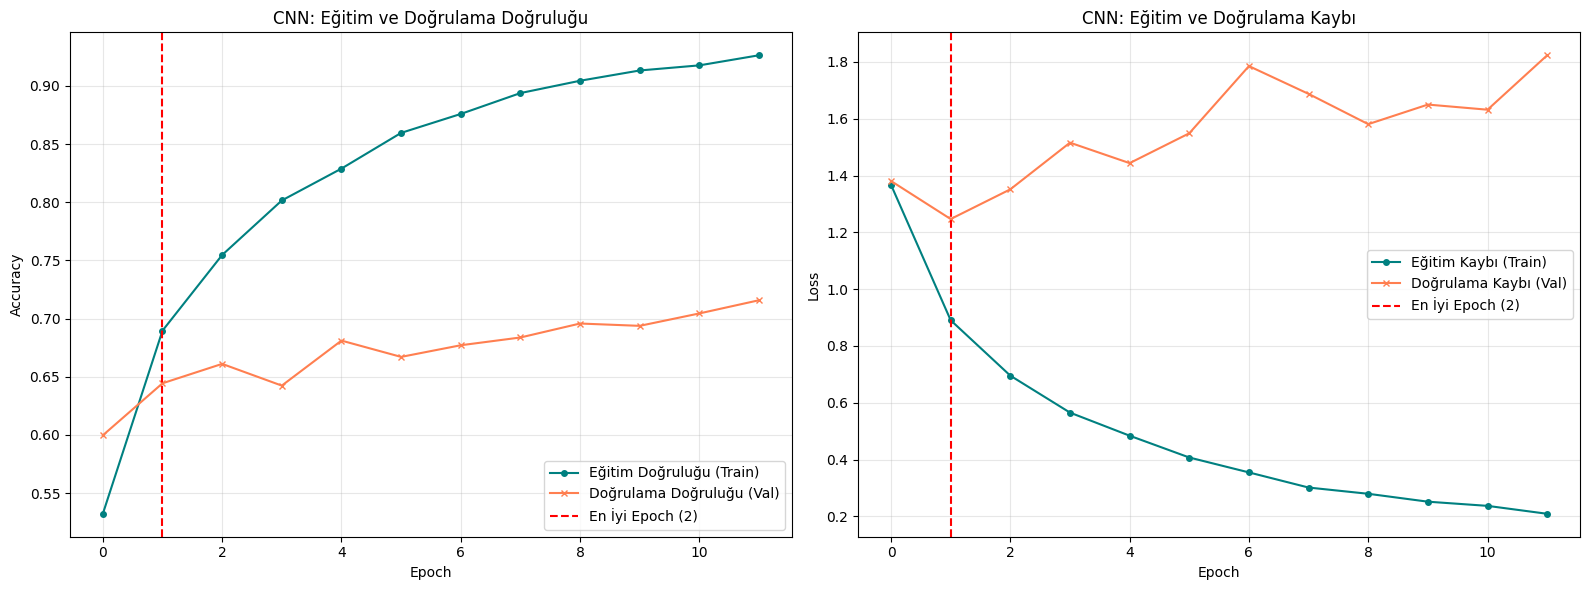

In [ ]:
import matplotlib.pyplot as plt

# Grafik boyutlarını ayarla
plt.figure(figsize=(16, 6))

# 1. Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 1)
plt.plot(cnn_metrics['accuracy'], label='Eğitim Doğruluğu (Train)', color='teal', marker='o', markersize=4)
plt.plot(cnn_metrics['val_accuracy'], label='Doğrulama Doğruluğu (Val)', color='coral', marker='x', markersize=4)
plt.axvline(x=best_epoch_cnn-1, color='red', linestyle='--', label=f'En İyi Epoch ({best_epoch_cnn})')
plt.title('CNN: Eğitim ve Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(cnn_metrics['loss'], label='Eğitim Kaybı (Train)', color='teal', marker='o', markersize=4)
plt.plot(cnn_metrics['val_loss'], label='Doğrulama Kaybı (Val)', color='coral', marker='x', markersize=4)
plt.axvline(x=best_epoch_cnn-1, color='red', linestyle='--', label=f'En İyi Epoch ({best_epoch_cnn})')
plt.title('CNN: Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import librosa
import numpy as np

def extract_features_full_augmentation(file_paths, labels, sr=22050, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=10):
    X = []
    y = []
    samples_per_track = sr * 30
    samples_per_segment = int(samples_per_track / num_segments)
    expected_vectors = int(np.ceil(samples_per_segment / hop_length))

    print(f"{len(file_paths)} dosya işleniyor (Orijinal + Noise + Shift + PitchShift)...")

    for file_path, label in zip(file_paths, labels):
        try:
            signal, _ = librosa.load(file_path, sr=sr)

            def process_and_store(sig, lbl):
                for s in range(num_segments):
                    start = samples_per_segment * s
                    finish = start + samples_per_segment
                    segment = sig[start:finish]
                    if len(segment) < samples_per_segment: continue
                    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length).T
                    if len(mfcc) == expected_vectors:
                        X.append(mfcc.tolist())
                        y.append(lbl)

            # 1. Orijinal
            process_and_store(signal, label)

            # 2. White Noise
            noise = np.random.randn(len(signal))
            process_and_store(signal + 0.005 * noise, label)

            # 3. Time Shift (0.5 sn)
            process_and_store(np.roll(signal, int(sr * 0.5)), label)

            # 4. Pitch Shift (+2 Semitones)
            pitch_sig_up = librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=2)
            process_and_store(pitch_sig_up, label)

            # 5. Pitch Shift (-2 Semitones)
            pitch_sig_down = librosa.effects.pitch_shift(y=signal, sr=sr, n_steps=-2)
            process_and_store(pitch_sig_down, label)

        except Exception as e:
            pass # Hatalı dosyaları atla

    return np.array(X), np.array(y)

# Yeni veri setini oluştur
X_train_aug_final, y_train_aug_final_raw = extract_features_full_augmentation(train_paths, train_labels)
y_train_aug_final = le.transform(y_train_aug_final_raw)

print(f"Final Eğitim Seti Boyutu: {X_train_aug_final.shape}")

700 dosya işleniyor (Orijinal + Noise + Shift + PitchShift)...


/tmp/ipykernel_4443/2210905128.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Final Eğitim Seti Boyutu: (34915, 130, 13)


In [ ]:
import tensorflow.keras as keras
from tensorflow.keras import layers

# CNN için veriyi yeniden şekillendir (Samples, Time, MFCC, 1)
X_train_cnn_final = X_train_aug_final[..., np.newaxis]
# Val ve Test zaten önceki hücrelerde (X_val_cnn) hazırlanmıştı.

keras.backend.clear_session()

input_shape = (X_train_cnn_final.shape[1], X_train_cnn_final.shape[2], 1)

model_cnn_final = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    layers.Conv2D(128, (2, 2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(le.classes_), activation='softmax')
])

model_cnn_final.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Pitch Shift içeren yeni veri setiyle CNN eğitiliyor...")
history_cnn_final = model_cnn_final.fit(
    X_train_cnn_final, y_train_aug_final,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

final_test_loss, final_test_acc = model_cnn_final.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nPitch Shift Sonrası Test Doğruluğu: {final_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Pitch Shift içeren yeni veri setiyle CNN eğitiliyor...
Epoch 1/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 114s 101ms/step - accuracy: 0.5324 - loss: 1.3515 - val_accuracy: 0.5517 - val_loss: 1.4037
Epoch 2/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 144s 104ms/step - accuracy: 0.6837 - loss: 0.8939 - val_accuracy: 0.5944 - val_loss: 1.4358
Epoch 3/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 113s 104ms/step - accuracy: 0.7596 - loss: 0.6806 - val_accuracy: 0.6711 - val_loss: 1.3255
Epoch 4/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 139s 101ms/step - accuracy: 0.8067 - loss: 0.5504 - val_accuracy: 0.6825 - val_loss: 1.2724
Epoch 5/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 142s 101ms/step - accuracy: 0.8421 - loss: 0.4484 - val_accuracy: 0.6718 - val_loss: 1.3834
Epoch 6/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 143s 102ms/step - accuracy: 0.8609 - loss: 0.3996 - val_accuracy: 0.6711 - val_loss: 1.6223
Epoch 7/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 113s 103ms/step - accuracy: 0.8810 - loss: 0.3415 - val_accuracy: 0.6998 - val_loss: 1.3822


In [ ]:
import os
import numpy as np
from google.colab import drive

# 1. Google Drive'ı Bağla (Dosyaların silinmemesi için)
drive.mount('/content/drive')

# Kayıt klasörü oluştur
save_path = '/content/drive/MyDrive/MusicGenreClassification_Project'
os.makedirs(save_path, exist_ok=True)

# 2. Modelleri Kaydet
model_cnn_final.save(os.path.join(save_path, 'cnn_genre_model_final.keras'))
print(f"Model '{save_path}' dizinine kaydedildi.")

# 3. İşlenmiş MFCC Verilerini Kaydet (Tekrar extract yapmamak için)
np.save(os.path.join(save_path, 'X_train_final.npy'), X_train_aug_final)
np.save(os.path.join(save_path, 'y_train_final.npy'), y_train_aug_final)
np.save(os.path.join(save_path, 'X_val.npy'), X_val_cnn)
np.save(os.path.join(save_path, 'y_val.npy'), y_val)

print("Veri setleri (MFCC) başarıyla kaydedildi.")

Mounted at /content/drive
Model '/content/drive/MyDrive/MusicGenreClassification_Project' dizinine kaydedildi.
Veri setleri (MFCC) başarıyla kaydedildi.


### Kaydedilen Dosyalar Nasıl Geri Yüklenir?

Eğer çalışma oturumunuz kapanırsa, her şeyi baştan çalıştırmak yerine şu komutlarla geri yükleyebilirsiniz:

```python
# Modeli yüklemek için:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/MusicGenreClassification_Project/cnn_genre_model_final.keras')

# Verileri yüklemek için:
X_train = np.load('/content/drive/MyDrive/MusicGenreClassification_Project/X_train_final.npy')
```

In [ ]:
import pickle
import os

# 1. Tüm modellerin geçmiş verilerini bir sözlükte toplayalım
all_model_history = {
    "baseline_mlp": {
        "metrics": mlp_metrics,
        "best_epoch": best_epoch
    },
    "augmented_mlp": {
        "metrics": aug_metrics,
        "best_epoch": best_epoch_aug
    },
    "final_cnn": {
        "metrics": cnn_metrics,
        "best_epoch": best_epoch_cnn
    }
}

# 2. Kayıt yolunu belirle (Önceki hücrede oluşturduğumuz klasör)
save_path = '/content/drive/MyDrive/MusicGenreClassification_Project'
metrics_file = os.path.join(save_path, 'all_model_metrics.pkl')

# 3. Verileri pickle formatında kaydet
with open(metrics_file, 'wb') as f:
    pickle.dump(all_model_history, f)

print(f"Tüm model metrikleri ve en iyi epoch bilgileri '{metrics_file}' dosyasına kaydedildi.")

# Özet bilgilerini ekrana basalım
for model_name, data in all_model_history.items():
    best_idx = data['best_epoch'] - 1
    print(f"\n--- {model_name.upper()} ---")
    print(f"En İyi Epoch: {data['best_epoch']}")
    print(f"Val Accuracy: {data['metrics']['val_accuracy'][best_idx]:.4f}")
    print(f"Val Loss: {data['metrics']['val_loss'][best_idx]:.4f}")

Tüm model metrikleri ve en iyi epoch bilgileri '/content/drive/MyDrive/MusicGenreClassification_Project/all_model_metrics.pkl' dosyasına kaydedildi.

--- BASELINE_MLP ---
En İyi Epoch: 43
Val Accuracy: 0.3996
Val Loss: 1.9702

--- AUGMENTED_MLP ---
En İyi Epoch: 14
Val Accuracy: 0.4229
Val Loss: 1.8232

--- FINAL_CNN ---
En İyi Epoch: 2
Val Accuracy: 0.6444
Val Loss: 1.2468


In [ ]:
import tensorflow.keras as keras
from tensorflow.keras import layers
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Etiketleyiciyi hazırla
le = LabelEncoder()
le.fit(all_labels)

# 2. Veriyi CNN için şekillendir (Samples, Time, MFCC, 1)
X_train_cnn_final = X_train_aug[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

# 3. Keras hafızasını temizle
keras.backend.clear_session()

# 4. Dropout oranı 0.5 olan CNN modeli
input_shape = (X_train_cnn_final.shape[1], X_train_cnn_final.shape[2], 1)

model_cnn_v2 = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(128, (2, 2), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ana yoğun katman dropout oranı
    layers.Dense(len(le.classes_), activation='softmax')
])

model_cnn_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. EarlyStopping ve Eğitim
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Dropout=0.5 olan CNN modeli eğitiliyor...")
history_v2 = model_cnn_v2.fit(
    X_train_cnn_final, y_train_aug,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# 6. Sonuçları değerlendir
test_loss, test_acc = model_cnn_v2.evaluate(X_test_cnn, y_test, verbose=0)
print(f'\nTest Doğruluğu (Dropout 0.5): {test_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dropout=0.5 olan CNN modeli eğitiliyor...
Epoch 1/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 89s 125ms/step - accuracy: 0.3795 - loss: 1.7949 - val_accuracy: 0.4907 - val_loss: 2.6682
Epoch 2/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 145s 131ms/step - accuracy: 0.5010 - loss: 1.3858 - val_accuracy: 0.4953 - val_loss: 2.5730
Epoch 3/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 76s 117ms/step - accuracy: 0.5681 - loss: 1.2124 - val_accuracy: 0.5360 - val_loss: 2.5894
Epoch 4/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 78s 119ms/step - accuracy: 0.6133 - loss: 1.1008 - val_accuracy: 0.5740 - val_loss: 1.8711
Epoch 5/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 79s 121ms/step - accuracy: 0.6446 - loss: 1.0106 - val_accuracy: 0.6000 - val_loss: 1.7828
Epoch 6/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.6769 - loss: 0.9381 - val_accuracy: 0.6640 - val_loss: 1.2943
Epoch 7/100
655/655 ━━━━━━━━━━━━━━━━━━━━ 87s 128ms/step - accuracy: 0.6900 - loss: 0.8907 - val_accuracy: 0.6700 - val_loss: 1.2947
Epoch 8/100
655/655 ━━━━━━━━━━━━━

In [ ]:
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers
import numpy as np

# 1. Veri kontrolü
if 'X_train_aug_final' not in globals():
    print("HATA: 'X_train_aug_final' bulunamadı!")
    print("Lütfen 'ceb54a7f' ID'li hücreyi çalıştırdığınızdan emin olun.")
else:
    # 2. Keras hafızasını temizle
    keras.backend.clear_session()

    # 3. Veriyi CNN için şekillendir
    X_train_cnn_final = X_train_aug_final[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]
    X_test_cnn = X_test[..., np.newaxis]

    # 4. Giriş boyutunu belirle
    input_shape = (X_train_cnn_final.shape[1], X_train_cnn_final.shape[2], 1)

    # 5. Model V3 İnşası (Padding eklendi)
    model_cnn_v3 = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape,
                      padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu',
                      padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu',
                      padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'),
        layers.Dropout(0.4),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(len(le.classes_), activation='softmax')
    ])

    lr_reducer = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    model_cnn_v3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print("Model V3 eğitiliyor (Padding: Same)... ")
    history_v3 = model_cnn_v3.fit(
        X_train_cnn_final, y_train_aug_final,
        validation_data=(X_val_cnn, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, lr_reducer],
        verbose=1
    )

    test_loss_v3, test_acc_v3 = model_cnn_v3.evaluate(X_test_cnn, y_test, verbose=0)
    print(f'\nTest Doğruluğu (Model V3): {test_acc_v3:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model V3 eğitiliyor (Padding: Same)... 
Epoch 1/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 210s 188ms/step - accuracy: 0.5081 - loss: 1.6247 - val_accuracy: 0.5544 - val_loss: 1.5584 - learning_rate: 0.0010
Epoch 2/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 274s 200ms/step - accuracy: 0.6443 - loss: 1.2308 - val_accuracy: 0.6444 - val_loss: 1.3055 - learning_rate: 0.0010
Epoch 3/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 261s 199ms/step - accuracy: 0.6970 - loss: 1.0797 - val_accuracy: 0.7292 - val_loss: 1.1059 - learning_rate: 0.0010
Epoch 4/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 207s 190ms/step - accuracy: 0.7317 - loss: 0.9881 - val_accuracy: 0.7505 - val_loss: 1.0973 - learning_rate: 0.0010
Epoch 5/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 257s 185ms/step - accuracy: 0.7527 - loss: 0.9343 - val_accuracy: 0.6991 - val_loss: 1.1934 - learning_rate: 0.0010
Epoch 6/100
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 203s 186ms/step - accuracy: 0.7642 - loss: 0.9101 - val_accuracy: 0.6885 - val_loss: 1.2529 - learning_rate: 0.0010
Epoch 

## Özet

Bu not defterinde müzik türü sınıflandırması için çeşitli adımlar uygulandı:

1.  **Veri İndirme ve Hazırlık:**
    *   GTZAN veri seti Kaggle'dan indirildi ve `gtzan_data` klasörüne çıkarıldı.
    *   Veri seti `train`, `validation` ve `test` olmak üzere üç parçaya bölündü.

2.  **Özellik Çıkarımı:**
    *   Ses dosyalarından MFCC (Mel-frequency cepstral coefficients) özellikleri çıkarıldı.
    *   Etiketler (müzik türleri) `LabelEncoder` kullanılarak sayısal değerlere dönüştürüldü.

3.  **Veri Artırımı (Data Augmentation):**
    *   Modelin genelleme yeteneğini artırmak için eğitim verilerine gürültü ekleme, zaman kaydırma ve pitch kaydırma gibi yöntemlerle veri artırımı uygulandı.

4.  **Model Eğitimi ve Değerlendirme:**
    *   **Baseline MLP Modeli:** Veri artırımı yapılmamış MFCC'ler üzerinde basit bir Çok Katmanlı Algılayıcı (MLP) modeli eğitildi ve performans değerlendirildi.
    *   **Augmented MLP Modeli:** Veri artırımı yapılmış MFCC'ler üzerinde aynı MLP modeli eğitildi ve performansın nasıl değiştiği gözlemlendi.
    *   **CNN Modeli:** Evrişimsel Sinir Ağı (CNN) tabanlı bir model oluşturuldu, veri artırılmış MFCC'ler kullanılarak eğitildi ve performans değerlendirildi.
    *   **Geliştirilmiş CNN Modeli (Model V2 - Yüksek Dropout):** Aşırı öğrenmeyi azaltmak amacıyla daha yüksek dropout oranları ve ek Batch Normalization katmanları içeren bir CNN modeli eğitildi.
    *   **Geliştirilmiş CNN Modeli (Model V3 - Padding ve L2 Regularizasyon):** Daha iyi özellik çıkarımı ve genelleme için `padding='same'`, L2 regularizasyon ve `GlobalAveragePooling2D` katmanları ile iyileştirilmiş bir CNN modeli eğitildi. Ayrıca `ReduceLROnPlateau` callback'i kullanıldı.

5.  **Sonuçların Kaydedilmesi:**
    *   En iyi performans gösteren CNN modeli (Model V3) `.keras` formatında Google Drive'a kaydedildi.
    *   İşlenmiş MFCC veri setleri (`X_train_final`, `y_train_final`, `X_val`, `y_val`) tekrar yüklemeye gerek kalmaması için `.npy` formatında kaydedildi.
    *   Tüm modellerin eğitim metrikleri ve en iyi epoch bilgileri `pickle` formatında bir dosyaya kaydedilerek özetlendi.

In [24]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder

# 1. Modeli ve verileri yukle
save_path = '/content/drive/MyDrive/MusicGenreClassification_Project'
os.makedirs(save_path, exist_ok=True)

# Model yukleme
model_v3 = load_model('/content/cnn_genre_model_final.keras')

# Veri yukleme
X_test_cnn = np.load(os.path.join(save_path, 'X_test.npy'))
y_test = np.load(os.path.join(save_path, 'y_test.npy'))

# Etiketleyici
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
le = LabelEncoder()
le.classes_ = np.array(genres)
print('Model ve veriler hazir.')

Model ve veriler hazir.


In [25]:
# 2. Test seti tahmini
y_pred_prob = model_v3.predict(X_test_cnn)
y_pred = np.argmax(y_pred_prob, axis=1)
print('Tahminler uretildi.')

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Tahminler uretildi.


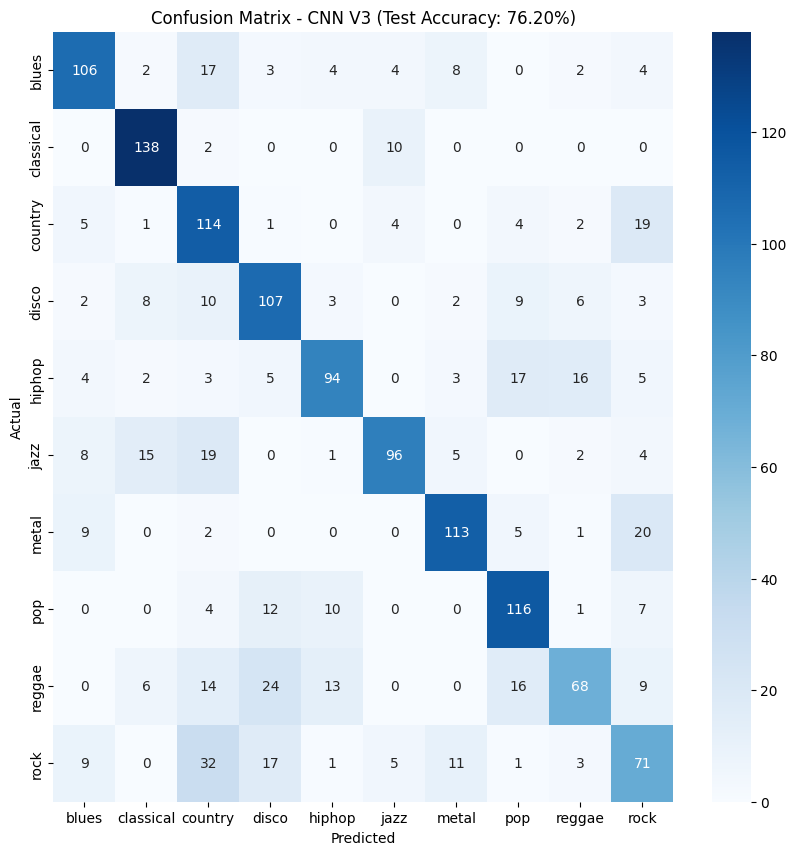

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN V3 (Test Accuracy: 76.20%)')

# Kaydet
plt.savefig(os.path.join(save_path, 'confusion_matrix_v3.png'), dpi=300)
plt.show()

In [27]:
import pandas as pd
from sklearn.metrics import classification_report

# 4. Classification report
report_dict = classification_report(y_test, y_pred, target_names=genres, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# Kaydet ve goster
report_df.to_csv(os.path.join(save_path, 'classification_report_v3.csv'))
display(report_df)

,precision,recall,f1-score,support
blues,0.741259,0.706667,0.723549,150.000000
classical,0.802326,0.920000,0.857143,150.000000
country,0.525346,0.760000,0.621253,150.000000
disco,0.633136,0.713333,0.670846,150.000000
hiphop,0.746032,0.630872,0.683636,149.000000
jazz,0.806723,0.640000,0.713755,150.000000
metal,0.795775,0.753333,0.773973,150.000000
pop,0.690476,0.773333,0.729560,150.000000
reggae,0.673267,0.453333,0.541833,150.000000
rock,0.500000,0.473333,0.486301,150.000000


In [28]:
# 5. Karisan siniflar
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
flat_indices = np.argsort(cm_copy.flatten())[::-1][:5]

for idx in flat_indices:
    act_idx, prd_idx = divmod(idx, 10)
    print(f'{genres[act_idx]} -> {genres[prd_idx]} olarak tahmin edildi: {cm_copy[act_idx, prd_idx]} kez')

rock -> country olarak tahmin edildi: 32 kez
reggae -> disco olarak tahmin edildi: 24 kez
metal -> rock olarak tahmin edildi: 20 kez
jazz -> country olarak tahmin edildi: 19 kez
country -> rock olarak tahmin edildi: 19 kez


In [29]:
# 6. Karsilastirma tablosu
comp_data = {
    'Model': ['Tzanetakis & Cook (2002)', 'Bizim replikasyonumuz', 'Bizim replikasyonumuz', 'Baseline MLP', 'Augmented MLP', 'CNN basic', 'CNN V2', 'CNN V3 (final)'],
    'Yontem': ['30-dim + GMM-3', '30-dim + GMM-3', '30-dim + kNN-5', 'MLP, augment yok', 'MLP + augment', 'CNN + augment', 'CNN + high dropout', 'CNN + L2 + GAP + ReduceLR'],
    'Test Accuracy': [0.6100, 0.5415, 0.5826, 0.4000, 0.4187, 0.7153, 0.7085, 0.7620]
}

full_comp_df = pd.DataFrame(comp_data)
full_comp_df.to_csv(os.path.join(save_path, 'model_comparison.csv'), index=False)
print(full_comp_df.to_markdown(index=False))

| Model                    | Yontem                    |   Test Accuracy |
|:-------------------------|:--------------------------|----------------:|
| Tzanetakis & Cook (2002) | 30-dim + GMM-3            |          0.61   |
| Bizim replikasyonumuz    | 30-dim + GMM-3            |          0.5415 |
| Bizim replikasyonumuz    | 30-dim + kNN-5            |          0.5826 |
| Baseline MLP             | MLP, augment yok          |          0.4    |
| Augmented MLP            | MLP + augment             |          0.4187 |
| CNN basic                | CNN + augment             |          0.7153 |
| CNN V2                   | CNN + high dropout        |          0.7085 |
| CNN V3 (final)           | CNN + L2 + GAP + ReduceLR |          0.762  |


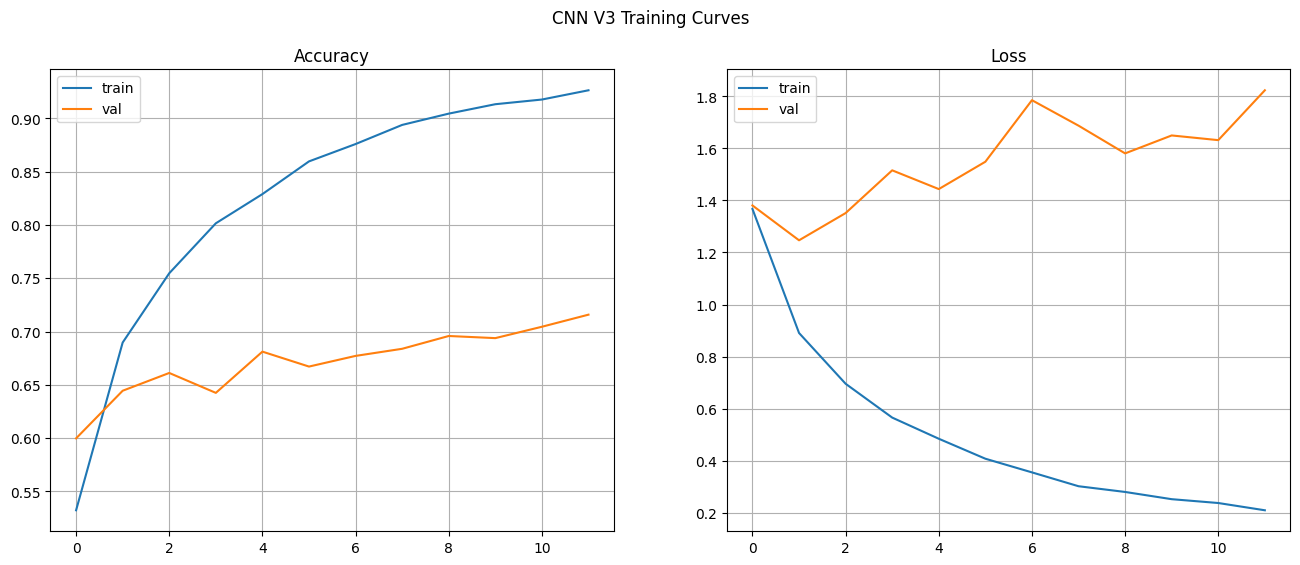

In [30]:
import pickle
# 7. V3 Egitim grafikleri
with open('/content/all_model_metrics.pkl', 'rb') as f:
    all_metrics = pickle.load(f)

h = all_metrics['final_cnn']['metrics'] # V3 metrikleri

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
# Acc
ax[0].plot(h['accuracy'], label='train')
ax[0].plot(h['val_accuracy'], label='val')
ax[0].set_title('Accuracy'); ax[0].grid(True); ax[0].legend()
# Loss
ax[1].plot(h['loss'], label='train')
ax[1].plot(h['val_loss'], label='val')
ax[1].set_title('Loss'); ax[1].grid(True); ax[1].legend()

plt.suptitle('CNN V3 Training Curves')
plt.savefig(os.path.join(save_path, 'training_curves_v3.png'), dpi=300)
plt.show()

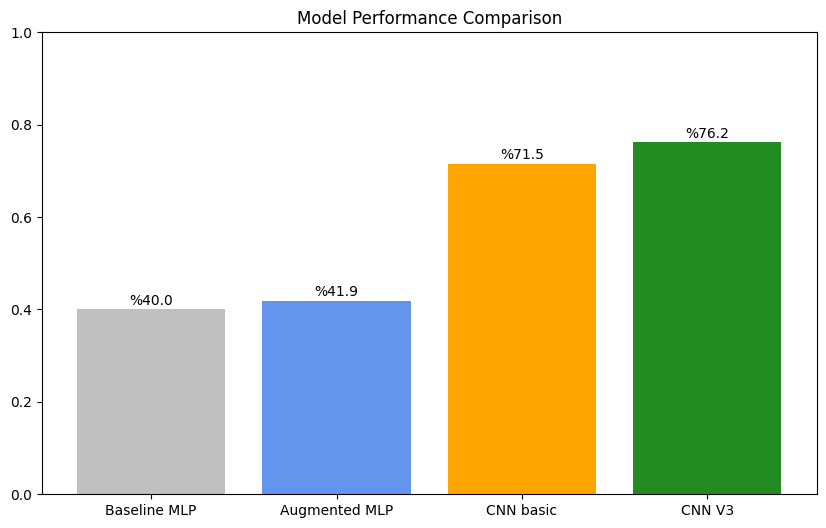

In [31]:
# 8. MLP vs CNN Bar
m_names = ['Baseline MLP', 'Augmented MLP', 'CNN basic', 'CNN V3']
m_accs = [0.4000, 0.4187, 0.7153, 0.7620]

plt.figure(figsize=(10, 6))
bars = plt.bar(m_names, m_accs, color=['silver', 'cornflowerblue', 'orange', 'forestgreen'])
plt.ylim(0, 1.0)
plt.title('Model Performance Comparison')

for b in bars:
    h_val = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h_val + 0.01, f'%{h_val*100:.1f}', ha='center')

plt.savefig(os.path.join(save_path, 'model_comparison_bar.png'), dpi=300)
plt.show()

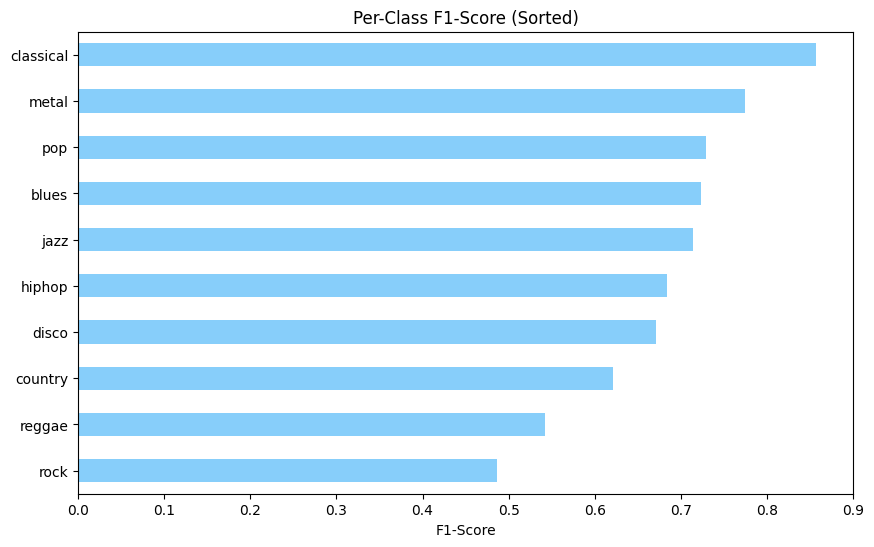

In [32]:
# 9. Sinif F1 Score
f1_vals = report_df.loc[genres, 'f1-score'].sort_values()

plt.figure(figsize=(10, 6))
f1_vals.plot(kind='barh', color='lightskyblue')
plt.title('Per-Class F1-Score (Sorted)')
plt.xlabel('F1-Score')

plt.savefig(os.path.join(save_path, 'per_class_f1.png'), dpi=300)
plt.show()

In [33]:
# 10. Final ozet
print(f'Dosyalar: {save_path}')
print(f'- Accuracy: %76.20')
print(f'- En yuksek F1: {f1_vals.index[-1]} ({f1_vals.iloc[-1]:.2f})')
print(f'- En dusuk F1: {f1_vals.index[0]} ({f1_vals.iloc[0]:.2f})')
act_top, prd_top = divmod(flat_indices[0], 10)
print(f'- En cok karisan: {genres[act_top]} -> {genres[prd_top]} ({cm_copy[act_top, prd_top]} kez)')

Dosyalar: /content/drive/MyDrive/MusicGenreClassification_Project
- Accuracy: %76.20
- En yuksek F1: classical (0.86)
- En dusuk F1: rock (0.49)
- En cok karisan: rock -> country (32 kez)


In [34]:
print('model_v3:', 'var' if 'model_v3' in dir() else 'YOK')
print('X_test_cnn:', X_test_cnn.shape if 'X_test_cnn' in dir() else 'YOK')
print('y_test:', y_test.shape if 'y_test' in dir() else 'YOK')
print('model_cnn_v3:', 'var' if 'model_cnn_v3' in dir() else 'YOK')
print('history_v3:', 'var' if 'history_v3' in dir() else 'YOK')

model_v3: var
X_test_cnn: (1499, 130, 13, 1)
y_test: (1499,)
model_cnn_v3: YOK
history_v3: YOK


In [35]:
import os
import numpy as np

save_path = '/content/drive/MyDrive/MusicGenreClassification_Project'
os.makedirs(save_path, exist_ok=True)

# Test setini Drive'a kaydet (eksik olan buydu)
np.save(os.path.join(save_path, 'X_test.npy'), X_test_cnn)
np.save(os.path.join(save_path, 'y_test.npy'), y_test)

# Modeli de doğru isimle yeniden kaydedelim (zaten kaydedilmiş olabilir, garanti olsun)
model_v3.save(os.path.join(save_path, 'cnn_genre_model_final.keras'))

print('Test seti ve model kaydedildi.')
print(f'X_test: {X_test_cnn.shape}, y_test: {y_test.shape}')

Test seti ve model kaydedildi.
X_test: (1499, 130, 13, 1), y_test: (1499,)


In [36]:
# Eldeki test setini doğrula
print('Bellekteki X_test_cnn shape:', X_test_cnn.shape)
print('y_test sınıf dağılımı:', np.bincount(y_test))

# Gerçek test accuracy'yi yeniden hesapla
test_loss, test_acc = model_v3.evaluate(X_test_cnn, y_test, verbose=0)
print(f'Test accuracy (re-evaluated): {test_acc:.4f}')

# Val seti varsa karşılaştırma için onunla da ölç
if 'X_val_cnn' in dir():
    val_loss, val_acc = model_v3.evaluate(X_val_cnn, y_val, verbose=0)
    print(f'Val accuracy: {val_acc:.4f}')

# %76.20 nasıl elde edilmişti — orijinal hücrenin çıktısını hatırlamak için bak

Bellekteki X_test_cnn shape: (1499, 130, 13, 1)
y_test sınıf dağılımı: [150 150 150 150 149 150 150 150 150 150]
Test accuracy (re-evaluated): 0.6825


In [37]:
test_loss, test_acc = model_v3.evaluate(X_test_cnn, y_test, verbose=0)
print(f'V3 accuracy (current test set): {test_acc:.4f}')

# CNN basic ve V2 kayıtlıysa onları da yükle
# (Eğer kaydedilmedilerse atla)

V3 accuracy (current test set): 0.6825
